In [152]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.express as px
import plotly.graph_objects as go

# Combinações

### Arquivos CSV e tratamento

In [153]:
df = pd.read_csv('/home/lucas/representation-fusion/resultados/combinacoes.csv')

#algumas coisas estavam erradas ao fazer a fusão: alguns estavam trocados 0 e 1 
# resultado invertido 

#1. PKLot, todos os que foram feitos com PKLot estão invertidos
mask_pklot = df['encoder'] == 'PKLot'
df.loc[mask_pklot, 'value'] = 1 - df.loc[mask_pklot, 'value']

#2. Kyoto + classificadores CNR (cameras) 
cameras = [
    'camera1', 'camera2', 'camera3', 'camera4', 'camera5',
    'camera6', 'camera7', 'camera8', 'camera9'
]

mask_kyoto_cnr = (
    (df['encoder'] == 'Kyoto') &
    (df['classificador'].isin(cameras))
)

df.loc[mask_kyoto_cnr, 'value'] = 1 - df.loc[mask_kyoto_cnr, 'value']


# 3. criar uma coluna de n_items (quantos itens tem a combinação)
df["n_items"] = df["combination"].apply(lambda x: str(x).split(",")).apply(len)
df = df[df['fusion_method'] != 'mean_probs']  # remover média pq é igual ao sum

## Contexto

No 1º artigo que foi recusado, publicamos usando sempre 10 modelos para a fusão, uma das recusas e sugestões foi testar com quantidades menores de modelos. Dessa forma, esse teste mostra os resultados com as fusões menores que 10 modelos. 

Como o André sugeriu, não precisavamos testar exatamente todas as combinações, apenas boa parte delas, então as combinações foram feitas da seguinte forma:
- Calcula o número total de combinações
- Pegava 50% delas de forma aleatória
- Exemplo: 
    - fusão de 3 modelos 
    - combinatória entre 10 (nº de modelos) x 3(para a fusão) = 120 possíveis combinações
    - 120 // 2 -> 60 combinações testadas


Sobre as fusões:
- Existem 4 tipos + comparativo:
    - Soma
    - Produto
    - Máximo
    - Votação

Sobre o protocolo de treinamento, foi separado da seguinte forma: Treino Encoder, Treino Classificador, Testes
- PKLot : [CNR1 - CNR9], [CNR1 - CNR9]
- CNR: [PUC, UFPR04, UFPR05], [PUC, UFPR04, UFPR05]
- Kyoto: [PUC, UFPR04, UFPR05, CNR1 - CNR9], [PUC, UFPR04, UFPR05, CNR1 - CNR9]

Os treinos com a base do classificador, poderia ter 5 tamanhos:
- 64
- 128
- 256
- 512 
- 1024

### Acurácia média para o tamanho da combinação

In [154]:
df.columns

Index(['encoder', 'classificador', 'teste', 'batch', 'n_models', 'combination',
       'fusion_method', 'value', 'n_items'],
      dtype='object')

Média da acurácia por tamanho da combinação, pelo batch e pelo encoder

In [155]:
df.groupby(['encoder','batch','n_items'])['value'].mean().reset_index().sort_values(['n_items', 'batch'])

,encoder,batch,n_items,value
0,CNR,64,2,0.830813
45,Kyoto,64,2,0.828377
90,PKLot,64,2,0.895647
9,CNR,128,2,0.864421
54,Kyoto,128,2,0.857206
...,...,...,...,...
80,Kyoto,512,10,0.892572
125,PKLot,512,10,0.925452
44,CNR,1024,10,0.930593
89,Kyoto,1024,10,0.905545


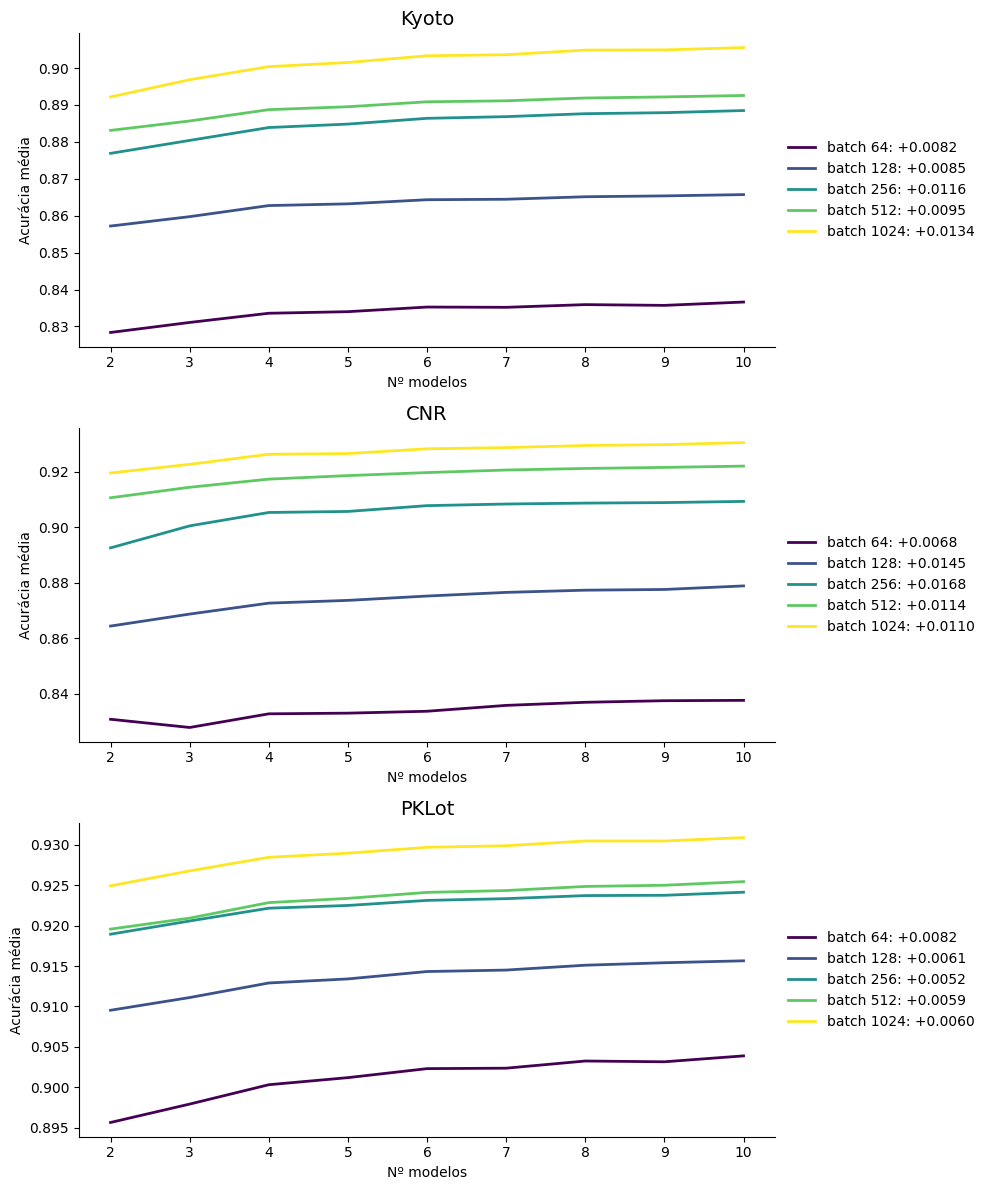

In [156]:
encoders = ['Kyoto', 'CNR', 'PKLot']
batches = [64, 128, 256, 512, 1024]

colors = plt.cm.viridis(np.linspace(0, 1, len(batches)))

fig, axes = plt.subplots(len(encoders), 1, figsize=(10, 12))

for i, encoder in enumerate(encoders):
    
    ax = axes[i]

    for j, batch in enumerate(batches):
        subset = df[
            (df['encoder'] == encoder) &
            (df['batch'] == batch)
        ]

        grouped = (
            subset
            .groupby('n_items')['value']
            .mean()
            .reset_index()
            .sort_values('n_items')
        )

        x = grouped['n_items'].values
        y = grouped['value'].values

        # ganho do primeiro para o último (ex: 2 → 10)
        gain = y[-1] - y[0]

        label = f"batch {batch}: +{gain:.4f}"

        ax.plot(
            x, y,
            label=label,
            color=colors[j],
            linewidth=2
        )

    ax.set_title(f'{encoder}', fontsize=14)
    ax.set_xlabel('Nº modelos')
    ax.set_ylabel('Acurácia média')

    # legenda fora
    ax.legend(
        loc='center left',
        bbox_to_anchor=(1, 0.5),
        frameon=False
    )

    # estilo clean
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Agora analisando caso a caso e vendo se faz diferença ou não o número de combinações aumentar

In [157]:
results = []

group_cols = ['encoder', 'classificador', 'teste', 'batch', 'fusion_method']

for keys, group in df.groupby(group_cols):
    
    group = group.sort_values('n_items')

    val_2  = group[group['n_items'] == 2]['value'].mean()
    val_10 = group[group['n_items'] == 10]['value'].mean()

    diff = val_10 - val_2

    results.append((*keys, val_2, val_10, diff))

df_diff = pd.DataFrame(results, columns=group_cols + ['val_2', 'val_10', 'diff'])

#### maior ganho

In [158]:
max_row = df_diff.loc[df_diff['diff'].idxmax()]
max_row

encoder               CNR
classificador      UFPR04
teste              UFPR05
batch                  64
fusion_method         max
val_2            0.690441
val_10           0.778406
diff             0.087965
Name: 100, dtype: object

#### análise do dataframe de diff

In [171]:
df_diff[df_diff['batch'] == 64].describe()

,batch,val_2,val_10,diff
count,936.0,936.000000,936.000000,936.000000
mean,64.0,0.851757,0.859947,0.008190
std,0.0,0.089289,0.091950,0.009064
min,64.0,0.565813,0.564762,-0.038482
25%,64.0,0.804188,0.813904,0.004371
50%,64.0,0.887052,0.896668,0.008383
75%,64.0,0.920285,0.929670,0.012463
max,64.0,0.961297,0.970522,0.087965


In [172]:
df_diff[df_diff['batch'] == 1024].describe()

,batch,val_2,val_10,diff
count,936.0,936.000000,936.000000,936.000000
mean,1024.0,0.904564,0.915286,0.010722
std,0.0,0.054285,0.051024,0.011445
min,1024.0,0.735612,0.728546,-0.039214
25%,1024.0,0.869106,0.885799,0.004500
50%,1024.0,0.921316,0.930117,0.007853
75%,1024.0,0.946475,0.953136,0.012997
max,1024.0,0.987844,0.989888,0.082084


#### maiores ganhos

In [160]:
df_diff.sort_values('diff', ascending=False).head(10)

,encoder,classificador,teste,batch,fusion_method,val_2,val_10,diff
100,CNR,UFPR04,UFPR05,64,max,0.690441,0.778406,0.087965
2858,Kyoto,camera9,UFPR04,1024,sum,0.813469,0.895553,0.082084
2857,Kyoto,camera9,UFPR04,1024,mult,0.813469,0.895345,0.081876
2859,Kyoto,camera9,UFPR04,1024,vote,0.813469,0.895005,0.081536
511,Kyoto,UFPR04,camera2,256,vote,0.846287,0.920391,0.074104
510,Kyoto,UFPR04,camera2,256,sum,0.846287,0.920391,0.074104
470,Kyoto,UFPR04,UFPR05,256,sum,0.738811,0.812034,0.073222
509,Kyoto,UFPR04,camera2,256,mult,0.846287,0.919414,0.073127
471,Kyoto,UFPR04,UFPR05,256,vote,0.738811,0.810719,0.071907
932,Kyoto,camera1,UFPR04,512,max,0.712639,0.781639,0.069000


- Os maiores ganhos acontecem sempre entre classificador x teste diferentes
- o que é um bom sinal para cross-domain
- Além disso, 9 dos 10 casos acontece na Kyoto, o que faz com que as fusões no STF (self taught learning) sejam mais impactadas por isso (grande maioria pq os valores estavam mais baixos e a fusão deixa os valores mais consistentes)

In [161]:
#outro exemplo doq falo acima, é que em 5% de ganho, a kyoto é a que mais tem (pode ser impacto por havar mais combinações dela, mas é um indicativo)
df_diff[df_diff['diff'] > 0.05].value_counts('encoder') #mesma coisa acontece com outros valores

encoder
Kyoto    32
CNR       2
Name: count, dtype: int64

#### maiores ganhos acima de 95%

In [162]:
df_diff[df_diff['val_2'] > 0.95].sort_values('diff', ascending=False).head(10)

,encoder,classificador,teste,batch,fusion_method,val_2,val_10,diff
74,CNR,UFPR04,PUC,512,sum,0.951082,0.967934,0.016853
75,CNR,UFPR04,PUC,512,vote,0.951082,0.967699,0.016617
73,CNR,UFPR04,PUC,512,mult,0.951082,0.967263,0.016181
77,CNR,UFPR04,PUC,1024,mult,0.957259,0.972625,0.015366
2956,Kyoto,camera9,camera4,1024,max,0.956333,0.970922,0.014588
161,CNR,UFPR05,UFPR05,64,mult,0.952435,0.966979,0.014543
78,CNR,UFPR04,PUC,1024,sum,0.957257,0.971432,0.014175
79,CNR,UFPR04,PUC,1024,vote,0.957257,0.971178,0.013920
162,CNR,UFPR05,UFPR05,64,sum,0.952435,0.966250,0.013815
160,CNR,UFPR05,UFPR05,64,max,0.952435,0.966121,0.013686


Nesse cenário, onde estou filtrando apenas para as acurácias altas, os resultados evidenciam
- CNR é a maior predominante
- A fusão melhora apenas 1% em acurácias altas


#### menor diferença

In [163]:
df_diff.sort_values('diff', ascending=True).head(10)

,encoder,classificador,teste,batch,fusion_method,val_2,val_10,diff
592,Kyoto,UFPR04,camera6,512,max,0.864473,0.812662,-0.051811
652,Kyoto,UFPR04,camera9,512,max,0.794729,0.745218,-0.049511
552,Kyoto,UFPR04,camera4,512,max,0.855720,0.806407,-0.049313
632,Kyoto,UFPR04,camera8,512,max,0.845544,0.798123,-0.047421
476,Kyoto,UFPR04,UFPR05,1024,max,0.800393,0.761179,-0.039214
103,CNR,UFPR04,UFPR05,64,vote,0.690441,0.651959,-0.038482
627,Kyoto,UFPR04,camera8,128,vote,0.790010,0.752325,-0.037684
626,Kyoto,UFPR04,camera8,128,sum,0.790010,0.754194,-0.035816
512,Kyoto,UFPR04,camera2,512,max,0.868010,0.833455,-0.034554
625,Kyoto,UFPR04,camera8,128,mult,0.790010,0.756726,-0.033283


Percebemos que em alguns casos, as fusões acabam piorando a performance, diminuindo até 5% da acurácia 


#### diferença média por encoder

In [164]:
df_diff.groupby(['encoder']).agg({'diff': ['mean', 'std', 'min', 'max']}).reset_index().sort_values(('diff', 'mean'), ascending=False)

encoder      diff                              
               mean       std       min       max
0     CNR  0.012087  0.014822 -0.038482  0.087965
1   Kyoto  0.010238  0.011587 -0.051811  0.082084
2   PKLot  0.006281  0.004525 -0.015046  0.032749

#### diferenças pelo método de fusão

In [169]:
df_diff.groupby(['fusion_method']).agg({'diff': ['mean', 'std', 'min', 'max']}).reset_index().sort_values(('diff', 'mean'), ascending=False)

fusion_method      diff                              
                     mean       std       min       max
1          mult  0.009750  0.009153 -0.033283  0.081876
0           max  0.009035  0.010639 -0.051811  0.087965
2           sum  0.008799  0.010125 -0.035816  0.082084
3          vote  0.008175  0.010362 -0.038482  0.081536

### Análisando o impacto de um autoencoder na combinação

In [176]:
import ast

df['combination'] = df['combination'].apply(ast.literal_eval)

for i in range(10):
    df[f'model_{i}'] = df['combination'].apply(lambda x: int(i in x))
    
df

,encoder,classificador,teste,batch,n_models,combination,fusion_method,value,n_items,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9
0,PKLot,camera1,camera2,64,2,"(3, 7)",sum,0.938706,2,0,0,0,1,0,0,0,1,0,0
2,PKLot,camera1,camera2,64,2,"(3, 7)",max,0.938706,2,0,0,0,1,0,0,0,1,0,0
3,PKLot,camera1,camera2,64,2,"(3, 7)",mult,0.938706,2,0,0,0,1,0,0,0,1,0,0
4,PKLot,camera1,camera2,64,2,"(3, 7)",vote,0.938706,2,0,0,0,1,0,0,0,1,0,0
5,PKLot,camera1,camera2,64,2,"(1, 9)",sum,0.938217,2,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2960094,Kyoto,camera9,PUC,1024,9,"(0, 2, 3, 4, 5, 6, 7, 8, 9)",vote,0.897823,9,1,0,1,1,1,1,1,1,1,1
2960095,Kyoto,camera9,PUC,1024,10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",sum,0.895574,10,1,1,1,1,1,1,1,1,1,1
2960097,Kyoto,camera9,PUC,1024,10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",max,0.868571,10,1,1,1,1,1,1,1,1,1,1
2960098,Kyoto,camera9,PUC,1024,10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)",mult,0.892641,10,1,1,1,1,1,1,1,1,1,1


### Impacto de cada modelo

<Axes: >

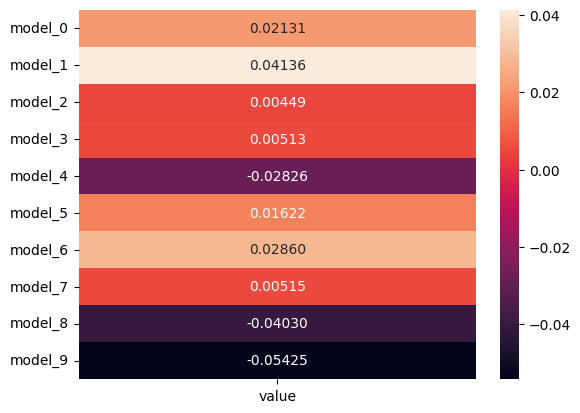

In [209]:
df_filter = df[df['n_items'] == 2]

corr_value = (
    df_filter[[f'model_{i}' for i in range(10)] + ['value']]
    .corr()['value']
    .drop('value')
)

sns.heatmap(
    corr_value.to_frame(),
    annot=True,
    fmt=".5f",
)

<Axes: >

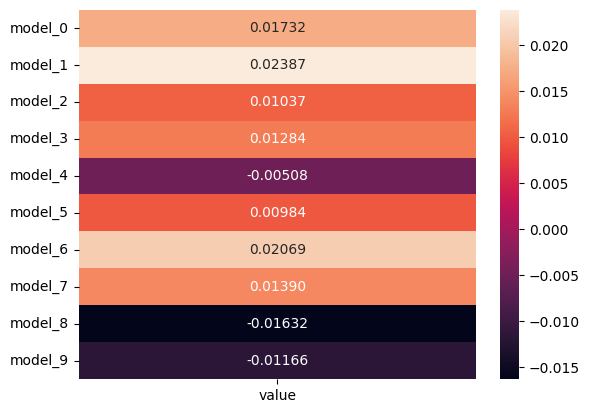

In [210]:
corr_value = (
    df[[f'model_{i}' for i in range(10)] + ['value']]
    .corr()['value']
    .drop('value')
)

sns.heatmap(
    corr_value.to_frame(),
    annot=True,
    fmt=".5f",
)

De forma geral, os modelos que mais impactam são o Modelo1 e Modelo6

### Impacto de cada modelo por Batch

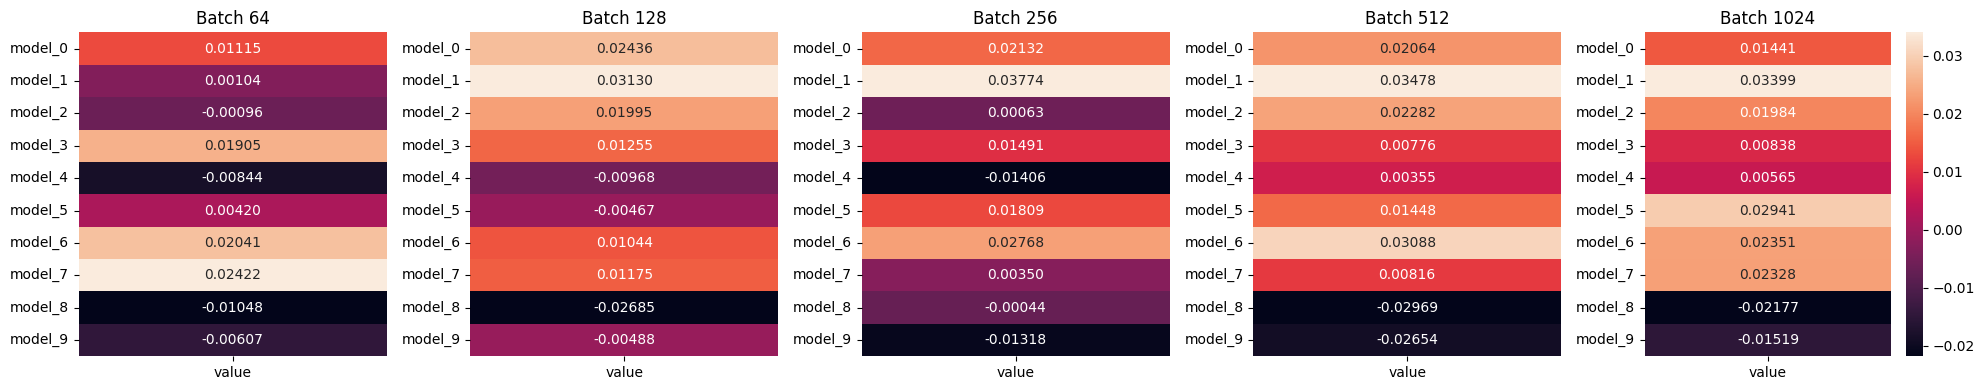

In [ ]:
batches = sorted(df['batch'].unique())

fig, axes = plt.subplots(1, len(batches), figsize=(20, 4))

for idx, batch in enumerate(batches):
    ax = axes[idx]

    df_filter = df[df['batch'] == batch]

    corr_value = (
        df_filter[[f'model_{i}' for i in range(10)] + ['value']]
        .corr()['value']
        .drop('value')
    )

    sns.heatmap(
        corr_value.to_frame(),
        annot=True,
        fmt=".5f",
        ax=ax,
        cbar=(idx == len(batches) - 1)  # só um colorbar
    )

    ax.set_title(f'Batch {batch}')

plt.tight_layout()
plt.show()

### Explicações para o impacto de cada modelo:

In [ ]:
import tensorflow as tf

for i in range(10):
    model = tf.keras.models.load_model(f'/home/lucas/representation-fusion/Modelos/Modelo_Kyoto-{i}/Classificador-PKLot/Estrutura/Classificador_Modelo_Kyoto-{i}.keras')
    model.summary()
    
